In [24]:
%pip install shap matplotlib
%pip install ipympl

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [21]:
import pandas as pd # data processing with CSV files
import numpy as np # linear algebra computations
import matplotlib.pyplot as plt # plotting graphs
%matplotlib widget

df_past_data = pd.read_csv(r'C:\Users\quin4\OneDrive\Documents\UofC_Masters\ENGG680_python\Assignment files\Assignment_1\Github_cloned\ENGG680_2025_Fall\ENGG680_Project\aligned_past_data_2.csv')
# Modifying historical dataframe 
df_past_data['date'] = pd.to_datetime(df_past_data['date'], format='%Y-%m-%d') 
#df_past_data['year'] = pd.to_datetime(df_past_data['year'], format='%Y') 
#df_past_data = df_past_data.set_index('date')
#print(df_past_data.head(5))
#print(df_past_data.dtypes)

df_past_ww = pd.read_csv(r'C:\Users\quin4\OneDrive\Documents\UofC_Masters\ENGG680_python\Assignment files\Assignment_1\Github_cloned\ENGG680_2025_Fall\ENGG680_Project\wastewater_only_covid_AB.csv')
df_past_ww = df_past_ww.rename(columns={'weekstart': 'date', 'w_avg': 'ww_concentration'})
df_past_ww['date'] = pd.to_datetime(df_past_ww['date'], format='%Y-%m-%d')
df_past_ww = df_past_ww.drop(['Location', 'EpiWeek', 'site', 'city', 'province', 'country', 'EpiYear','measureid', 'min', 'max', 'pruid'], axis=1)
#df_past_ww = df_past_ww.set_index('date')
#print(df_past_ww.head(5))

# Creating consistent dates for the historical data
# ww start 2021-02-07, each week, end 2025-09-07
# data start 2020-01-25, per day(ish), end 2023-12-07

# Find the integer location for a specific date
start_date = df_past_data.index[df_past_data['date'] == '2021-02-07']
#print(start_date)
df_past_data = df_past_data.loc[379:]
df_past_data = df_past_data.reset_index(drop=True)
#print(df_past_ww.loc[140:150])
end_date = df_past_ww.index[df_past_ww['date'] == '2023-12-03']
df_past_ww = df_past_ww.loc[:147]

ww_dates = df_past_ww['date'].tolist()
data_dates = df_past_data['date'].tolist()

total_dates = ww_dates + data_dates
unique_dates_list = list(dict.fromkeys(total_dates))

ww_data_interpolated_to_data_dates = pd.DataFrame(unique_dates_list, columns =['date'])
past_data_interpolated_to_ww_dates = pd.DataFrame(unique_dates_list, columns =['date'])


for i in range(len(unique_dates_list)):
    if unique_dates_list[i] in ww_dates:
        index_in_ww = ww_dates.index(unique_dates_list[i])
        ww_data_interpolated_to_data_dates.loc[i, 'ww_concentration'] = df_past_ww.loc[index_in_ww, 'ww_concentration']
    else:
        # find the closest previous date in ww_dates
        previous_dates = [d for d in ww_dates if d < unique_dates_list[i]]
        if previous_dates:
            closest_date = max(previous_dates)
            index_in_ww = ww_dates.index(closest_date)
            ww_data_interpolated_to_data_dates.loc[i, 'ww_concentration'] = df_past_ww.loc[index_in_ww, 'ww_concentration']
        else:
            ww_data_interpolated_to_data_dates.loc[i, 'ww_concentration'] = np.nan
#print(ww_data_interpolated_to_data_dates.head(10))
#print(len(unique_dates_list))
#print(len(ww_data_interpolated_to_data_dates))
sorted_ww_interpolated = ww_data_interpolated_to_data_dates.sort_values(by='date').reset_index(drop=True)
#print(sorted_ww_interpolated.head(5))
#print(sorted_ww_interpolated.tail(5))

plt.plot(sorted_ww_interpolated['date'], sorted_ww_interpolated['ww_concentration'], label = 'interpolated', color = 'green')
plt.plot(df_past_ww['date'], df_past_ww['ww_concentration'], label = 'original', color = 'orange')
plt.xlabel('Date')
plt.ylabel('WW Concentration')
plt.title('WW Concentration Over Time with Interpolated Dates')
plt.show()

plt.plot(df_past_ww['date'], df_past_ww['ww_concentration'])
plt.xlabel('Date')
plt.ylabel('WW Concentration')
plt.title('Original WW Concentration Over Time')
plt.show()

for i in range(len(unique_dates_list)):
    if unique_dates_list[i] in data_dates:
        index_in_data = data_dates.index(unique_dates_list[i])
        past_data_interpolated_to_ww_dates.loc[i, 'total_cases'] = df_past_data.loc[index_in_data, 'total_cases']
        past_data_interpolated_to_ww_dates.loc[i, 'total_deaths'] = df_past_data.loc[index_in_data, 'total_deaths']
        past_data_interpolated_to_ww_dates.loc[i, 'total_hospitalizations'] = df_past_data.loc[index_in_data, 'total_hospitalizations']
        past_data_interpolated_to_ww_dates.loc[i, 'total_ICU'] = df_past_data.loc[index_in_data, 'total_ICU']
        past_data_interpolated_to_ww_dates.loc[i, 'total_vaccinated'] = df_past_data.loc[index_in_data, 'total_vaccinated']
    else:
        # find the closest previous date in data_dates
        previous_dates = [d for d in data_dates if d < unique_dates_list[i]]
        if previous_dates:
            closest_date = max(previous_dates)
            index_in_data = data_dates.index(closest_date)
            past_data_interpolated_to_ww_dates.loc[i, 'total_cases'] = df_past_data.loc[index_in_data, 'total_cases']
            past_data_interpolated_to_ww_dates.loc[i, 'total_deaths'] = df_past_data.loc[index_in_data, 'total_deaths']
            past_data_interpolated_to_ww_dates.loc[i, 'total_hospitalizations'] = df_past_data.loc[index_in_data, 'total_hospitalizations']
            past_data_interpolated_to_ww_dates.loc[i, 'total_ICU'] = df_past_data.loc[index_in_data, 'total_ICU']
            past_data_interpolated_to_ww_dates.loc[i, 'total_vaccinated'] = df_past_data.loc[index_in_data, 'total_vaccinated']
        else:
            past_data_interpolated_to_ww_dates.loc[i, 'total_cases'] = np.nan
            past_data_interpolated_to_ww_dates.loc[i, 'total_deaths'] = np.nan
            past_data_interpolated_to_ww_dates.loc[i, 'total_hospitalizations'] = np.nan
            past_data_interpolated_to_ww_dates.loc[i, 'total_ICU'] = np.nan
            past_data_interpolated_to_ww_dates.loc[i, 'total_vaccinated'] = np.nan

sorted_data_interpolated = past_data_interpolated_to_ww_dates.sort_values(by='date').reset_index(drop=True)

plt.plot(sorted_data_interpolated['date'], sorted_data_interpolated['total_cases'], label = 'interpolated', color = 'red')
plt.plot(df_past_data['date'], df_past_data['total_cases'], label = 'original', color = 'blue')
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.title('Cases Over Time with Interpolated Dates')
plt.legend()
plt.show()



RuntimeError: 'widget' is not a recognised GUI loop or backend name

--- Starting ICU Demand and Cost Forecasting Project ---
Mock Data Loaded (Total Rows: 500)
Total Features Used: 19

--- Training Model 1: ICU Load Forecast ---
--- Training Model 2: Operational Cost Estimation ---


Evaluation for Predicted ICU Load (Patients):
  R-squared (R²): 0.7006
  Mean Absolute Error (MAE): 6.13
  Root Mean Squared Error (RMSE): 7.70


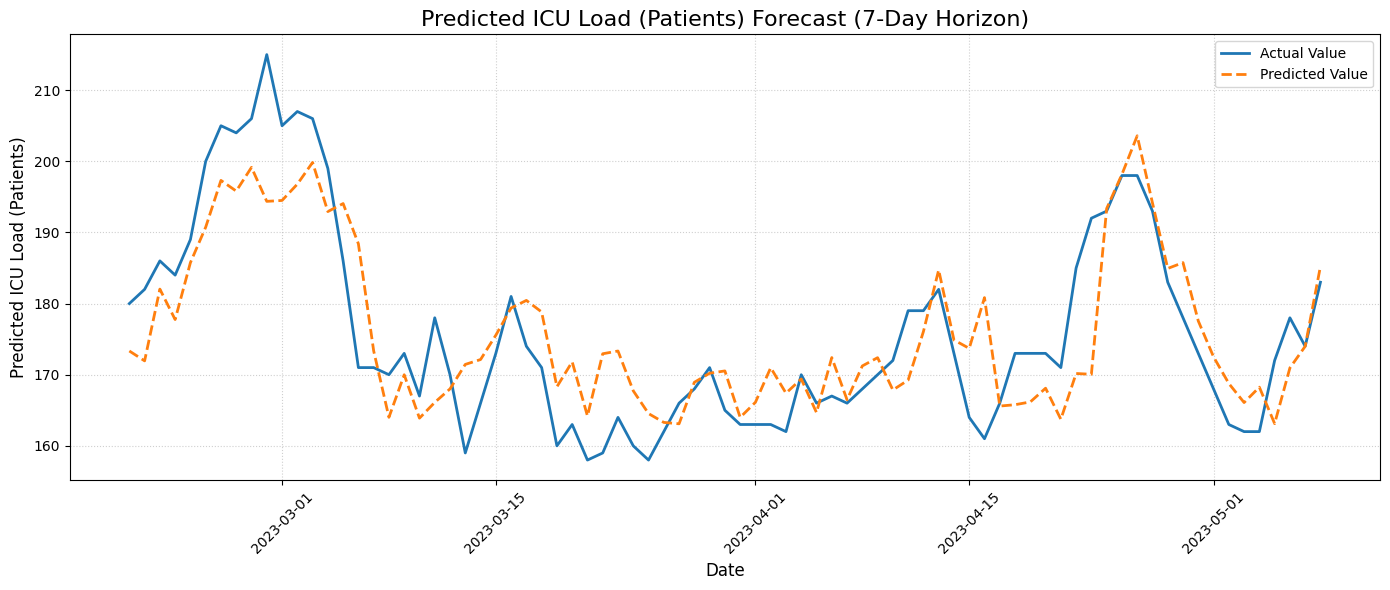

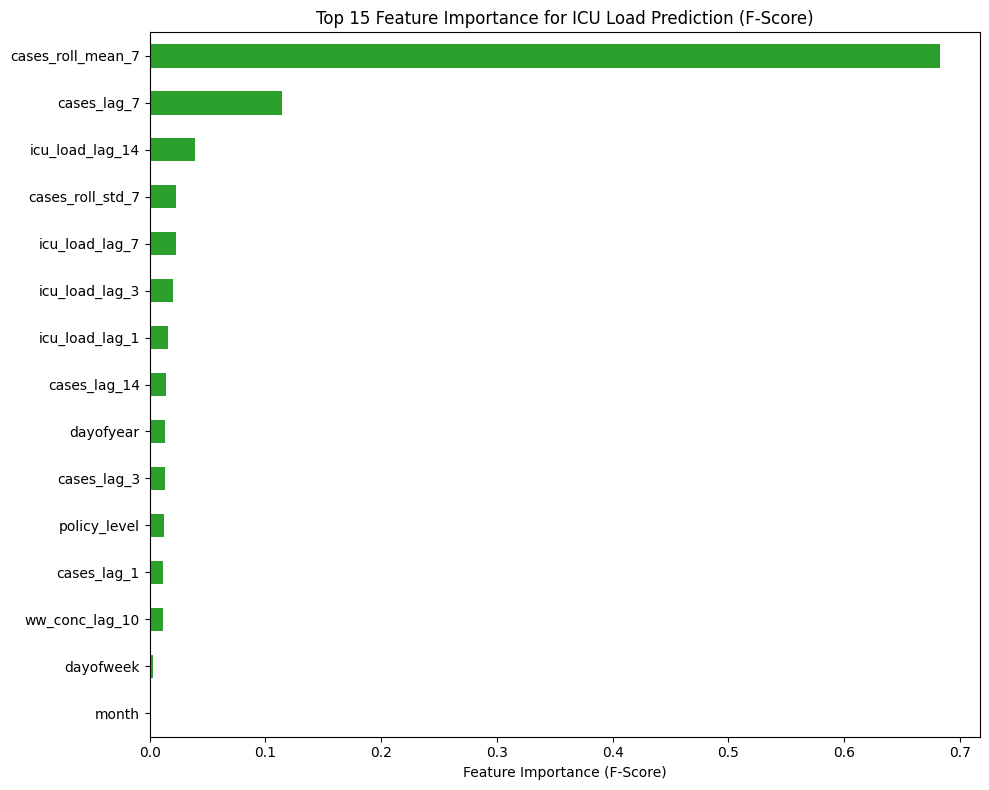


--- Generating SHAP Explanation ---


C:\Users\quin4\AppData\Local\Temp\ipykernel_7304\1731865882.py:327: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


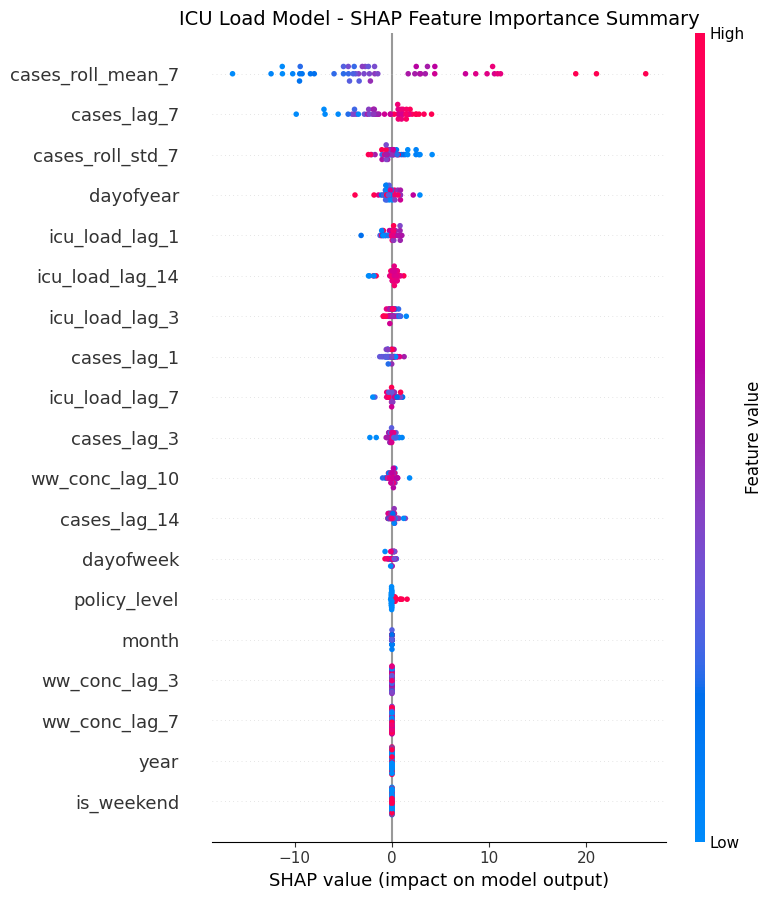


--- Starting Robust Iterative 30-Day Forecast ---
Robust Iterative Forecast Complete.

30-Day Iterative Forecast Results (First 5 Days):
            Predicted ICU Load
2023-05-22                 164
2023-05-23                 169
2023-05-24                 170
2023-05-25                 169
2023-05-26                 168

Pipeline Execution Complete. Check plots for results and feature importance.


In [ ]:
import pandas as pd # data processing with CSV files
import numpy as np # linear algebra computations
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import matplotlib.pyplot as plt
import shap

# --- 0. Configuration and Data Setup ---
# Define the prediction horizon (L days ahead)
PREDICTION_HORIZON_DAYS = 7 
# Define the Cost Proxy factors (BASED ON CIHI DATA - Cost estimates .csv)
# CIHI data shows Avg ICU cost is ~35,125 CAD over 13.5 days.
# We set a base admission cost and a daily operational cost reflecting this.
COST_PER_ADMISSION = 36384  # Data-informed cost for confirmed and suspected covid diagnosis testing. Based on CIHI data from 2023-2024
COST_PER_PATIENT_DAY_ICU = 2432.68  # Data-informed cost for daily operational cost. Based on CIHI data from 2023-2024 (Average cost of hosptitalization with ICU / average length of stay in days =$82711 / 34 days)
EMMERGENCY_ICU_CAPACITY = 450  # Data-informed emmergency ICU capacity for Alberta, from Alberta Health Services
NORMAL_IUC_CAPACITY = 393 # Data-informed current ICU capacity for Alberta, from Alberta Health Services
#NUM_HOSPITALS_AB = 
#---------------------------------------------------------------------------------------------------------------
# Define historical data in csv files
#---------------------------------------------------------------------------------------------------------------
# Past infection, death, hospitalization, vaccination data for Alberta
df_past_data = pd.read_csv(r'C:\Users\quin4\OneDrive\Documents\UofC_Masters\ENGG680_python\Assignment files\Assignment_1\Github_cloned\ENGG680_2025_Fall\ENGG680_Project\aligned_past_data_2.csv')
# Modifying historical dataframe 
df_past_data['date'] = pd.to_datetime(df_past_data['date'], format='%Y-%m-%d') 
df_past_data['year'] = pd.to_datetime(df_past_data['year'], format='%Y') 
#df_past_data = df_past_data.rename(columns={'date':'dates', 'total_cases':'new_cases', 'total_ICU':'icu_admissions', 'wastewater':'wastewater_conc'})

#---------------------------------------------------------------------------------------------------------------
# Define current data in csv files for forecasting
#---------------------------------------------------------------------------------------------------------------
# Wastewater testing data
df_current_AB_wastewater_covid = pd.read_csv(r'C:\Users\quin4\OneDrive\Documents\UofC_Masters\ENGG680_python\Assignment files\Assignment_1\Github_cloned\ENGG680_2025_Fall\ENGG680_Project\AB_wastewater_25-26.csv')
# Vaccination data 
df_current_AB_vaccination_covid = pd.read_csv(r'C:\Users\quin4\OneDrive\Documents\UofC_Masters\ENGG680_python\Assignment files\Assignment_1\Github_cloned\ENGG680_2025_Fall\ENGG680_Project\AB_vaccines_25-26.csv')
# Creating one dataframe to contain all current data (for forecasting)
df_current_ww_vax = pd.merge(df_current_AB_wastewater_covid, df_current_AB_vaccination_covid, how = 'right', on='week_start')
df_current_ww_vax['week_start'] = pd.to_datetime(df_current_ww_vax['week_start'], format='%Y-%m-%d')
# Modifying current data (for forecasting)
df_current_ww_vax = df_current_ww_vax.rename(columns={'week_start':'dates', 'Covid_vaccines_administered':'new_vaccines', 'Total_cases':'new_cases'})
df_current_ww_vax = df_current_ww_vax.drop('week_number', axis = 1)
df_current_ww_vax['AB_wastewater_conc'] = df_current_ww_vax['ww_Lethbridge'] + df_current_ww_vax['ww_Calgary'] + df_current_ww_vax['ww_Edmonton'] + df_current_ww_vax['ww_Red_Deer'] + df_current_ww_vax['ww_Fort_Mcmurray'] + df_current_ww_vax['ww_Grande_Prairie'] + df_current_ww_vax['ww_Fort_Saskatchewan'] + df_current_ww_vax['ww_MedicineHat']

def create_historical_data():
    """
    Creates a time-series DataFrame representing historical daily Covid data for Alberta Dec 2020 - June 2024
    """
           
    # Target 1 (ICU Load Percentage)
    df_past_data['icu_load'] = df_past_data['total_ICU']/NORMAL_IUC_CAPACITY * 100  # Percentage of ICU capacity filled
    # Target 2 (hopspital admissions not ICU)
    df_past_data['hospital_load'] = df_past_data['total_hospitalization']-df_past_data['total_ICU']
    # Target 3 (Operational Cost - The Proxy Variable, now using better factors)
    df_past_data['operational_cost'] = (df_past_data['icu_admissions'] * COST_PER_ADMISSION) + \
                             (df_past_data['icu_load'] * COST_PER_PATIENT_DAY)
    df_past_data['operational_cost'] = df['operational_cost'] + np.random.normal(0, 50000) # Add some noise
    df_past_data['operational_cost'] = np.maximum(100000, df['operational_cost'])
    

    return df.dropna().astype({'policy_level': int})


# --- 1. Data Loading and Feature Engineering ---

def create_features(df_past_data, look_ahead):
    """
    Generates all time-series features (Lags, Rolling Averages, Calendar)
    and defines the target variable shifted by 'look_ahead' days.
    """
    # --- A. Calendar Features (for Seasonality) ---
    df_past_data['dayofweek'] = df_past_data.index.dayofweek
    df_past_data['dayofyear'] = df_past_data.index.dayofyear
    df_past_data['month'] = df_past_data.index.month
    df_past_data['year'] = df_past_data.index.year
    df_past_data['is_weekend'] = df_past_data.index.dayofweek.isin([5, 6]).astype(int)

    # --- B. Lag Features (Crucial for Time Series) ---
    for lag in [1, 3, 7, 14]:
        df_past_data[f'icu_load_lag_{lag}'] = df_past_data['icu_load'].shift(lag)
        df_past_data[f'cases_lag_{lag}'] = df_past_data['new_cases'].shift(lag)
    
    # Wastewater is a LEADING indicator, so use smaller, leading lags
    for lag in [3, 7, 10]:
        df_past_data[f'ww_conc_lag_{lag}'] = df_past_data['wastewater_conc'].shift(lag)

    # --- C. Rolling Window Features (for Trend and Noise Reduction) ---
    df['cases_roll_mean_7'] = df['new_cases'].rolling(window=7).mean()
    df['cases_roll_std_7'] = df['new_cases'].rolling(window=7).std()

    # --- D. Define Target (Shifted for Prediction) ---
    # Target Y1: ICU Load L days in the future
    df['ICU_Load_Target'] = df['icu_load'].shift(-look_ahead)

    # Target Y2: Operational Cost L days in the future
    df['Cost_Target'] = df['operational_cost'].shift(-look_ahead)
    
    df = df.dropna() 
    return df

# --- Function for Hyperparameter Tuning (Unchanged) ---
def tune_model_with_random_search(X_train, Y_train):
    """
    Uses RandomizedSearchCV to find optimal hyperparameters for XGBoost.
    """
    print("\n--- Starting Hyperparameter Tuning (Random Search) ---")
    
    param_grid = {
        'n_estimators': [100, 500, 1000],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7, 9],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0]
    }
    
    xgb = XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)
    tscv_search = TimeSeriesSplit(n_splits=3)
    
    random_search = RandomizedSearchCV(
        estimator=xgb, 
        param_distributions=param_grid, 
        n_iter=10, 
        scoring='neg_mean_squared_error', 
        cv=tscv_search, 
        verbose=1, 
        random_state=42,
        n_jobs=-1
    )
    
    random_search.fit(X_train, Y_train)
    
    print(f"Best parameters found: {random_search.best_params_}")
    
    best_model = XGBRegressor(**random_search.best_params_, objective='reg:squarederror', random_state=42, n_jobs=-1)
    return best_model

# --- 2. Chained Model Pipeline Functions (FIXED) ---

def train_chained_pipeline(df_processed, features, target_y1, target_y2, perform_tuning=False):
    """
    Trains Model 1 (ICU Load) and Model 2 (Cost) using a TimeSeriesSplit.
    """
    
    # Use TimeSeriesSplit for validation
    tscv = TimeSeriesSplit(n_splits=5)
    train_index, test_index = list(tscv.split(df_processed))[4]

    X_train, X_test = df_processed.iloc[train_index][features], df_processed.iloc[test_index][features]
    Y1_train, Y1_test = df_processed.iloc[train_index][target_y1], df_processed.iloc[test_index][target_y1]
    # Keep raw cost targets for Model 2 evaluation
    Y2_train_raw, Y2_test_raw = df_processed.iloc[train_index][target_y2], df_processed.iloc[test_index][target_y2] 

    # --- Scaling ---
    scaler = MinMaxScaler() # Feature scaler
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

    # Initialize and fit a separate scaler for the COST TARGET (Y2)
    cost_scaler = MinMaxScaler()
    # Reshape training data for scaler compatibility and fit
    Y2_train_scaled = cost_scaler.fit_transform(Y2_train_raw.values.reshape(-1, 1)).flatten()
    # Y2_test_raw remains unscaled for accurate evaluation metrics

    
    # --- Model 1: ICU Load Forecasting (Y1) ---
    print("\n--- Training Model 1: ICU Load Forecast ---")
    
    if perform_tuning:
        model_icu = tune_model_with_random_search(X_train_scaled_df, Y1_train)
        model_icu.fit(X_train_scaled_df, Y1_train)
    else:
        model_icu = XGBRegressor(
            objective='reg:squarederror', 
            n_estimators=1000, 
            learning_rate=0.05, 
            max_depth=5,
            random_state=42,
            n_jobs=-1
        )
        model_icu.fit(X_train_scaled_df, Y1_train)
    
    Y1_pred = model_icu.predict(X_test_scaled_df)
    
    # --- Model 2: Operational Cost Estimation (Y2) ---
    print("--- Training Model 2: Operational Cost Estimation ---")
    
    # Features for Model 2 training: Original features + ACTUAL ICU Load (Y1_train)
    features_m2_train = X_train_scaled_df.copy()
    features_m2_train['predicted_icu_load'] = Y1_train
    
    # Use slightly simplified parameters for Model 2 as the task is relatively less complex
    model_cost = XGBRegressor(
        objective='reg:squarederror', 
        n_estimators=300, 
        learning_rate=0.1, 
        max_depth=3, 
        random_state=42,
        n_jobs=-1
    )
    # Train Model 2 on the SCALED COST TARGET
    model_cost.fit(features_m2_train, Y2_train_scaled)

    # --- Final Chained Prediction for Cost ---
    # Features for Model 2 testing: Original features + PREDICTED ICU Load (Y1_pred)
    features_m2_test = X_test_scaled_df.copy()
    features_m2_test['predicted_icu_load'] = Y1_pred
    
    # Predict the SCALED cost
    Y2_pred_scaled = model_cost.predict(features_m2_test)
    
    # Inverse transform the prediction back to the original CAD value for evaluation
    Y2_pred = cost_scaler.inverse_transform(Y2_pred_scaled.reshape(-1, 1)).flatten()

    # Return the raw (unscaled) test targets for evaluation
    return Y1_pred, Y1_test, Y2_pred, Y2_test_raw, model_icu, scaler 

# --- Function for Iterative Long-Range Forecast (Unchanged) ---
def iterative_forecast(model, scaler, df_raw_history, features, look_ahead, days_to_predict=30):
    """
    Performs an iterative, long-range forecast.
    """
    print(f"\n--- Starting Robust Iterative {days_to_predict}-Day Forecast ---")
    
    RAW_COLS = ['icu_load', 'new_cases', 'wastewater_conc', 'policy_level', 'icu_admissions', 'operational_cost']
    current_raw_df = df_raw_history[RAW_COLS].copy()
    
    last_date = current_raw_df.index[-1]
    future_forecasts = []
    
    for i in range(1, days_to_predict + 1):
        
        forecast_date = last_date + pd.Timedelta(days=i)
        
        new_raw_row = {
            'icu_load': 0, 
            'new_cases': current_raw_df['new_cases'].iloc[-1],
            'wastewater_conc': current_raw_df['wastewater_conc'].iloc[-1],
            'icu_admissions': current_raw_df['icu_admissions'].iloc[-1],
            'policy_level': current_raw_df['policy_level'].iloc[-1],
            'operational_cost': 0,
        }
        
        if i > 1:
            new_raw_row['icu_load'] = future_forecasts[-1]
        else:
            new_raw_row['icu_load'] = current_raw_df['icu_load'].iloc[-1]


        temp_df = pd.DataFrame(new_raw_row, index=[forecast_date])
        current_raw_df = pd.concat([current_raw_df, temp_df])
        
        processed_temp = create_features(current_raw_df, look_ahead=0) 
        
        X_predict_raw = processed_temp.iloc[[-1]][features]
        
        X_scaled = scaler.transform(X_predict_raw)
        
        Y_next = model.predict(X_scaled)[0]
        Y_next = np.maximum(0, Y_next).round().astype(int)
        
        future_forecasts.append(Y_next)
        
        current_raw_df.loc[forecast_date, 'icu_load'] = Y_next

    forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=look_ahead), periods=days_to_predict, freq='D')
    forecast_results = pd.DataFrame({
        'Predicted ICU Load': future_forecasts
    }, index=forecast_dates)
    
    print("Robust Iterative Forecast Complete.")
    return forecast_results


# --- 3. Evaluation and Visualization (Unchanged) ---

def evaluate_and_plot(Y_pred, Y_test, title):
    """Calculates metrics and plots Actual vs. Predicted."""
    
    mae = mean_absolute_error(Y_test, Y_pred)
    mse = mean_squared_error(Y_test, Y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(Y_test, Y_pred)

    print(f"\nEvaluation for {title}:")
    print(f"  R-squared (R²): {r2:.4f}")
    print(f"  Mean Absolute Error (MAE): {mae:,.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:,.2f}")

    # Plotting
    plt.figure(figsize=(14, 6))
    plt.plot(Y_test.index, Y_test.values, label='Actual Value', color='#1f77b4', linewidth=2)
    plt.plot(Y_test.index, Y_pred, label='Predicted Value', color='#ff7f0e', linestyle='--', linewidth=2)
    plt.title(f'{title} Forecast ({PREDICTION_HORIZON_DAYS}-Day Horizon)', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel(title, fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()
    #  (This tag is contextual and helpful)

# --- Function for SHAP Visualization (Unchanged) ---
def plot_shap_summary(model, X_data, feature_names, title):
    """
    Calculates and plots SHAP values for model explainability.
    """
    print("\n--- Generating SHAP Explanation ---")
    
    explainer = shap.TreeExplainer(model)
    
    X_sample = X_data.sample(n=min(50, len(X_data)), random_state=42)
    shap_values = explainer.shap_values(X_sample.values) 
    
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values, 
        X_sample, 
        feature_names=feature_names, 
        show=False,
        plot_type="dot" 
    )
    plt.title(f'{title} - SHAP Feature Importance Summary', fontsize=14)
    plt.tight_layout()
    plt.show(block=False) 
    #  (This tag is contextual and helpful)
    
# --- 4. Main Execution ---

if __name__ == '__main__':
    print("--- Starting ICU Demand and Cost Forecasting Project ---")
    
    # Step 1: Data Preparation
    data = create_mock_data()
    print(f"Mock Data Loaded (Total Rows: {len(data)})")

    # Step 2: Feature Engineering
    df_final = create_features(data.copy(), PREDICTION_HORIZON_DAYS) 
    
    target_y1 = 'ICU_Load_Target'
    target_y2 = 'Cost_Target'
    
    EXCLUDE_COLS = ['new_cases', 'wastewater_conc', 'icu_admissions', 'icu_load', 
                    'operational_cost', target_y1, target_y2]
    features = [col for col in df_final.columns if col not in EXCLUDE_COLS]
    print(f"Total Features Used: {len(features)}")
    
    # Step 3: Train Chained Pipeline (FIXED)
    Y1_pred, Y1_test, Y2_pred, Y2_test, model_icu, scaler = train_chained_pipeline(
        df_final, features, target_y1, target_y2, perform_tuning=False
    )
    
    # Step 4: Evaluation and Visualization
    print("\n========================================================")
    
    # Evaluate Model 1 (ICU Load)
    evaluate_and_plot(Y1_pred, Y1_test, 'Predicted ICU Load (Patients)')

    # Evaluate Model 2 (Operational Cost - NOW CORRECTLY SCALED)
    #evaluate_and_plot(Y2_pred, Y2_test, 'Predicted Operational Cost (CAD)')
    
    # Feature Importance (Standard XGBoost)
    plt.figure(figsize=(10, 8))
    importance = pd.Series(model_icu.feature_importances_, index=features).sort_values(ascending=False).head(15)
    importance.plot(kind='barh', color='#2ca02c')
    plt.title('Top 15 Feature Importance for ICU Load Prediction (F-Score)')
    plt.xlabel('Feature Importance (F-Score)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show(block=False)
    #  (This tag is contextual and helpful)

    # SHAP Explanations
    X_full_scaled = scaler.transform(df_final[features])
    X_full_scaled_df = pd.DataFrame(X_full_scaled, columns=features, index=df_final.index)
    plot_shap_summary(model_icu, X_full_scaled_df, features, 'ICU Load Model')

    # Run the Iterative Forecast
    long_range_forecast = iterative_forecast(
        model_icu, 
        scaler, 
        data, 
        features, 
        PREDICTION_HORIZON_DAYS, 
        days_to_predict=30
    )
    
    print("\n30-Day Iterative Forecast Results (First 5 Days):")
    print(long_range_forecast.head())

    plt.show()

    print("\n========================================================")
    print("Pipeline Execution Complete. Check plots for results and feature importance.")